# *Laboratório III - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*
## Operações Pontuais e Filtro de Média
Atividade desenvolvida para obtenção de nota parcial da disciplina de PDI - 2026.1.


## Parte I: Equalização de Histogramas
Nessa primeira parte, faremos a implementação de equalização de histograma.

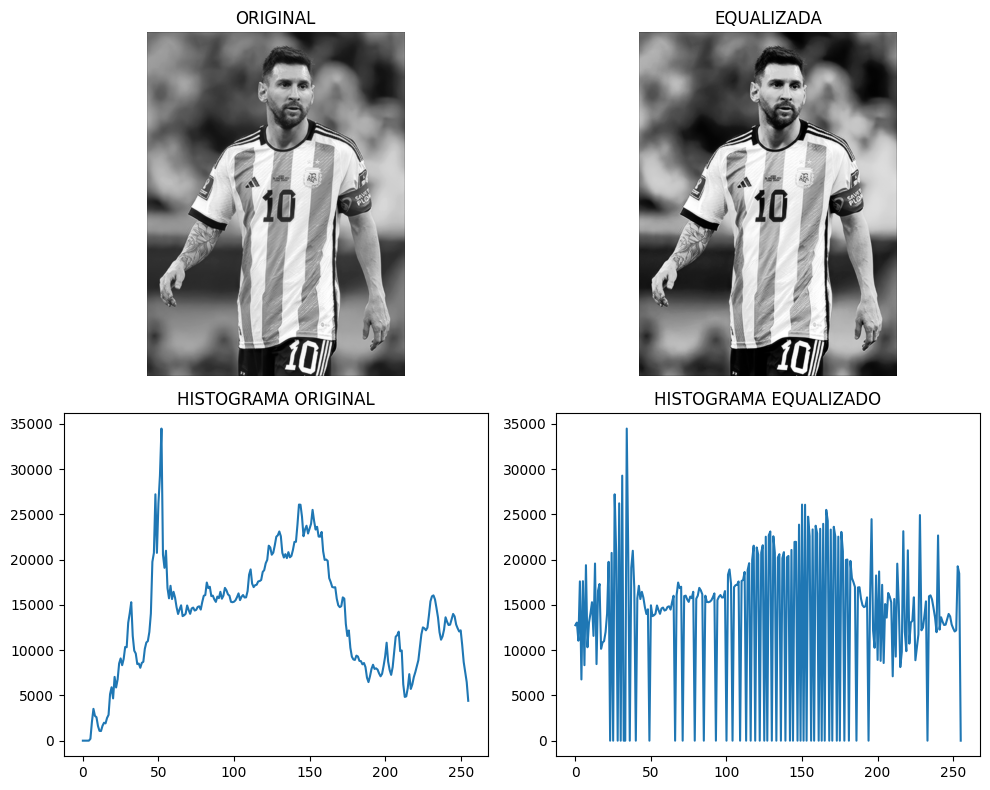

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

IMG = cv2.imread("messi.jpg")
IMG_GRAY = cv2.cvtColor(IMG, cv2.COLOR_BGR2GRAY)

# HISTOGRAMA
HIST_DATA = cv2.calcHist([IMG_GRAY], [0], None, [256], [0, 256]).flatten()


# NORMALIZAÇÃO
NUM_PIXELS = IMG_GRAY.size
PDF = HIST_DATA / NUM_PIXELS

# CDF
CDF = np.zeros(256)
CDF[0] = PDF[0]
for I in range(1, 256):
    CDF[I] = CDF[I-1] + PDF[I]

# TRANSFORMAÇÃO
L = 256
TRANSFORM = np.floor((L - 1) * CDF).astype(np.uint8)

# APLICAR TRANSFORMAÇÃO
IMG_EQ = np.zeros_like(IMG_GRAY)
ROWS, COLS = IMG_GRAY.shape

for I in range(ROWS):
    for J in range(COLS):
        IMG_EQ[I, J] = TRANSFORM[IMG_GRAY[I, J]]

# HISTOGRAMA EQUALIZADO
HIST_EQ = np.zeros(256, dtype=int)
for PIXEL in IMG_EQ.flatten():
    HIST_EQ[PIXEL] += 1

# PLOT FINAL
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(IMG_GRAY, cmap='gray')
plt.title("ORIGINAL")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(IMG_EQ, cmap='gray')
plt.title("EQUALIZADA")
plt.axis('off')

plt.subplot(2,2,3)
plt.plot(HIST_DATA)
plt.title("HISTOGRAMA ORIGINAL")

plt.subplot(2,2,4)
plt.plot(HIST_EQ)
plt.title("HISTOGRAMA EQUALIZADO")

plt.tight_layout()
plt.show()

Perguntas para reflexão  
*Discuta as limitações da equalização global tal como implementada.*  
A equalização global de histograma aplica uma única transformação baseada na distribuição de intensidades da imagem inteira, o que pode levar à perda de detalhes locais e ao realce excessivo de ruído em regiões homogêneas; além disso, se a imagem já possui bom contraste em certas áreas, a técnica pode degradar essas regiões ao redistribuir intensidades de forma indiscriminada, também falhando em imagens com iluminação não uniforme, onde diferentes partes exigiriam ajustes distintos.  

*Diferencie a equalização global da adaptativa (CLAHE): em que cenários CLAHE produz resultados superiores? Pesquise a respeito. Não precisa implementar.*  
A equalização global usa um único histograma para toda a imagem, enquanto a equalização adaptativa, como o CLAHE, divide a imagem em pequenas regiões e equaliza cada uma localmente, limitando o contraste para evitar amplificação de ruído; o CLAHE é superior em cenários com iluminação desigual, imagens médicas, visão computacional em ambientes reais e qualquer situação com variações locais de contraste, pois preserva melhor detalhes em diferentes áreas sem superexpor ou saturar regiões específicas.  

## Parte II: Operações Pontuais Não-homogêneas  
Nessa segunda parte, aplicaremos uma transformação não-homogênea para aumento de brilho (g = min(f + c, L − 1)).  


C:\Users\Pedro\AppData\Local\Temp\ipykernel_11324\1111580061.py:20: RuntimeWarning: overflow encountered in scalar add
  VAL = IMG_GRAY[I, J] + C


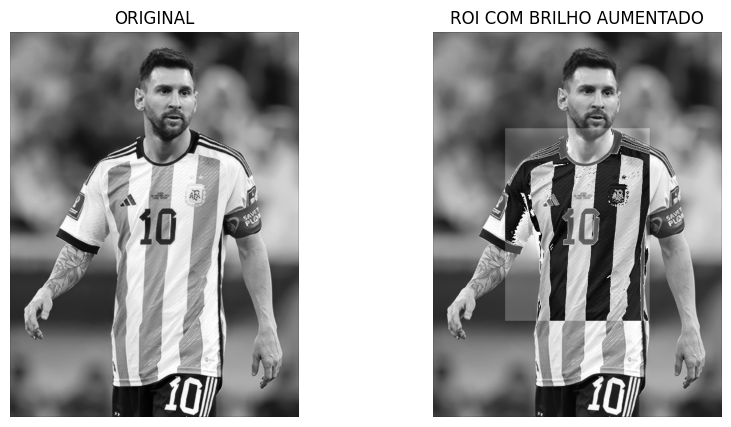

In [3]:
# parâmetro de brilho
C = 50
L = 256

# dimensões
ROWS, COLS = IMG_GRAY.shape

# ROI central (retângulo)
R_START = ROWS // 4
R_END   = 3 * ROWS // 4
C_START = COLS // 4
C_END   = 3 * COLS // 4

# cópia da imagem
IMG_OUT = IMG_GRAY.copy()

# aplicar transformação só no ROI
for I in range(R_START, R_END):
    for J in range(C_START, C_END):
        VAL = IMG_GRAY[I, J] + C
        if VAL > (L - 1):
            VAL = L - 1
        IMG_OUT[I, J] = VAL

# plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(IMG_GRAY, cmap='gray')
plt.title("ORIGINAL")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(IMG_OUT, cmap='gray')
plt.title("ROI COM BRILHO AUMENTADO")
plt.axis('off')

plt.show()

Perguntas para reflexão  
*Avalie o impacto visual da operação local e da descontinuidade na borda da ROI (se percebida).*  
O impacto visual da operação local é um aumento perceptível de intensidade na ROI, tornando detalhes nessa região mais visíveis; porém, como a transformação é abrupta (não homogênea), pode surgir uma descontinuidade visível na borda do retângulo, especialmente se o valor de C for alto, criando um efeito artificial de “bloco” ou transição brusca entre regiões, o que pode comprometer a naturalidade da imagem.

*Discuta aplicações práticas: realce seletivo em imagens médicas, correção de exposição em regiões específicas.*  
Em aplicações práticas, esse tipo de operação é útil para realce seletivo, como em imagens médicas (por exemplo, destacar uma área suspeita em uma radiografia) ou na correção de exposição em fotografia, onde apenas partes subexpostas precisam de ajuste; no entanto, na prática costuma-se usar técnicas mais suaves (como máscaras com transição gradual ou métodos adaptativos) para evitar descontinuidades e preservar a qualidade visual.  

## Parte III: Filtro de Média 3×3  
Nessa terceira parte, implementaremos um filtro passa-baixa que é o filtro de média 3x3.  

C:\Users\Pedro\AppData\Local\Temp\ipykernel_11324\579859963.py:11: RuntimeWarning: overflow encountered in scalar add
  SUM += IMG[I+DI, J+DJ]


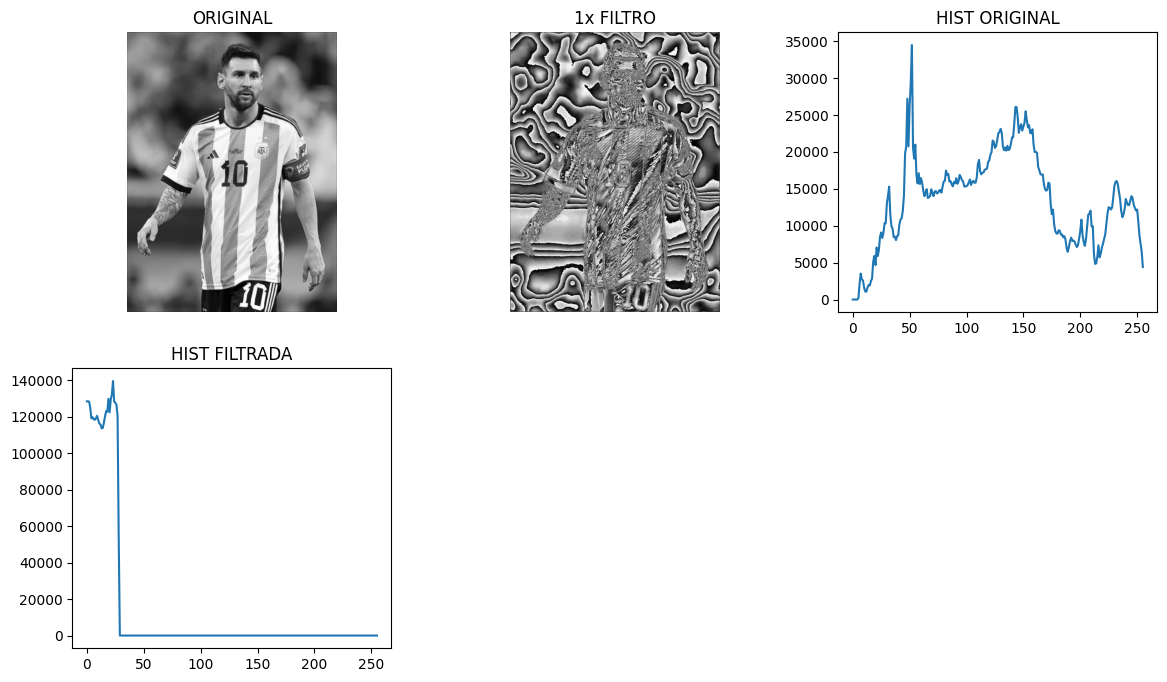

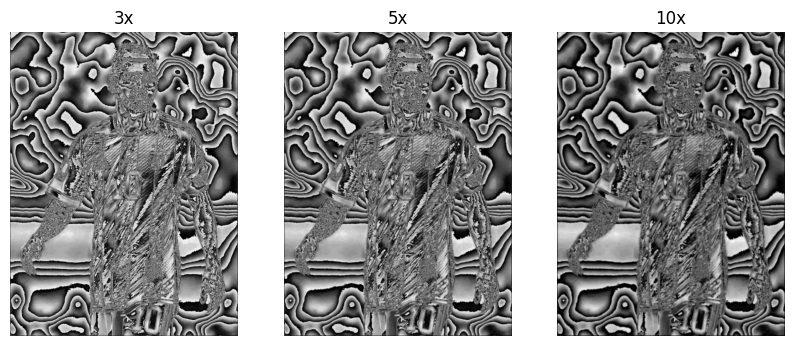

In [5]:
def MEAN_FILTER_3X3(IMG):
    ROWS, COLS = IMG.shape
    OUT = np.zeros_like(IMG)

    # ignorando bordas 
    for I in range(1, ROWS-1):
        for J in range(1, COLS-1):
            SUM = 0
            for DI in [-1, 0, 1]:
                for DJ in [-1, 0, 1]:
                    SUM += IMG[I+DI, J+DJ]
            OUT[I, J] = SUM // 9  # média inteira

    return OUT

# aplicação
IMG_F1 = MEAN_FILTER_3X3(IMG_GRAY)
#aplicações repetidas
IMG_F3 = IMG_GRAY.copy()
for _ in range(3):
    IMG_F3 = MEAN_FILTER_3X3(IMG_F3)

IMG_F5 = IMG_GRAY.copy()
for _ in range(5):
    IMG_F5 = MEAN_FILTER_3X3(IMG_F5)

IMG_F10 = IMG_GRAY.copy()
for _ in range(10):
    IMG_F10 = MEAN_FILTER_3X3(IMG_F10)



# histogramas
def HIST(IMG):
    H = np.zeros(256, dtype=int)
    for P in IMG.flatten():
        H[P] += 1
    return H

H_ORIG = HIST(IMG_GRAY)
H_F1   = HIST(IMG_F1)

# visualização
plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(IMG_GRAY, cmap='gray')
plt.title("ORIGINAL")
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(IMG_F1, cmap='gray')
plt.title("1x FILTRO")
plt.axis('off')
plt.subplot(2,3,3)
plt.plot(H_ORIG)
plt.title("HIST ORIGINAL")
plt.subplot(2,3,4)
plt.plot(H_F1)
plt.title("HIST FILTRADA")
plt.show()

# segunda figura para ver melhor evolução
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(IMG_F3, cmap='gray')
plt.title("3x")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(IMG_F5, cmap='gray')
plt.title("5x")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(IMG_F10, cmap='gray')
plt.title("10x")
plt.axis('off')
plt.show()

Perguntas para reflexão   
Observe o efeito de blurring (suavização):   
*• Perda progressiva de detalhes finos.*    
Com a aplicação sucessiva do filtro de média 3×3, observa-se uma perda progressiva de detalhes finos, pois a operação atua como um passa-baixa que suaviza variações rápidas de intensidade; texturas e pequenas estruturas vão desaparecendo à medida que o número de iterações aumenta, deixando a imagem visualmente mais “lisa”.    

*• Redução de ruído gaussiano.*  
Há também redução de ruído gaussiano, já que o filtro de média atenua flutuações aleatórias ao fazer a média dos vizinhos; quanto mais vezes o filtro é aplicado, maior é a supressão do ruído, embora isso venha acompanhado da perda de informação útil.   

*• Bordas menos definidas (verificar com gradiente de Sobel).*  
As bordas tornam-se menos definidas porque o filtro reduz os gradientes locais; ao aplicar o operador de Sobel (por exemplo, com cv2.Sobel) na imagem original e na filtrada, percebe-se que as magnitudes do gradiente diminuem após a suavização, indicando transições mais suaves entre regiões — ou seja, as bordas ficam borradas e menos detectáveis.  


## Análise final

*Qual técnica apresentou maior impacto visual? Justifique.*  
A técnica com maior impacto visual foi a equalização global de histograma, pois altera a distribuição de intensidades de toda a imagem, aumentando significativamente o contraste e revelando detalhes que antes estavam comprimidos em faixas estreitas de intensidade; diferentemente do filtro de média (que suaviza) ou do ajuste local de brilho (que afeta apenas uma região), a equalização modifica globalmente a percepção da imagem, gerando mudanças mais evidentes.  

*Em que situações a equalização de histograma pode prejudicar a imagem?*  
A equalização de histograma pode prejudicar a imagem quando já existe bom contraste local, pois pode superestimar certas regiões e introduzir aparência artificial; também amplifica ruído em áreas homogêneas e pode distorcer níveis de cinza importantes, o que é crítico em imagens médicas ou científicas onde a fidelidade dos valores de intensidade é relevante.  

*Quais são as limitações do filtro de média em relação a filtros como o Gaussiano ou o Mediano?*  
 O filtro de média possui limitações importantes: ele borra bordas e detalhes, pois trata todos os pixels igualmente; em comparação, o filtro Gaussiano realiza uma suavização mais natural ao ponderar vizinhos pela distância, enquanto o filtro mediano é mais robusto a ruídos impulsivos (como sal e pimenta), preservando melhor as bordas, algo que o filtro de média não consegue fazer.  

*Como operações pontuais não homogêneas podem ser usadas na análise de imagens médicas ou de satélite?*  
Operações pontuais não homogêneas são úteis quando se deseja atuar seletivamente em regiões específicas, como realçar uma área suspeita em exames médicos ou ajustar o brilho/contraste em regiões de interesse em imagens de satélite; isso permite melhorar a visibilidade de alvos sem degradar o restante da imagem, sendo especialmente útil em cenários com iluminação ou relevância espacial não uniforme.  

*De que forma o tamanho do kernel afeta o resultado do filtro de média? Existe um limite prático?*  
O tamanho do kernel no filtro de média controla o nível de suavização: kernels maiores produzem mais borramento e maior redução de ruído, mas também eliminam mais detalhes e degradam bordas; existe um limite prático, pois kernels muito grandes tornam a imagem excessivamente lisa e pouco informativa, além de aumentarem o custo computacional, sendo comum usar tamanhos pequenos (como 3×3 ou 5×5) para equilibrar suavização e preservação de detalhes.  